In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

cs = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/DataExport_office_v2.xlsx')
ff = pd.read_excel('../data/FEDFUNDS (1).xlsx')
bond = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/bond_yield_10yr.xlsx')
rrp = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/real_risk_premieum.csv')
inf_e = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/Inflation expectations (1).xlsx')
cmbs = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/commercial_mortgage.csv')
gdp = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/GDP.csv')

#create a subset where column Population is greater than 500000
cs = cs[cs['Population'] > 500000]

#convert to time series
def convert_period_to_datetime(period):
	parts = period.split('Q')
	year = parts[0].strip()
	quarter = parts[1].strip().split()[0]
	month = (int(quarter) - 1) * 3 + 1
	return pd.Timestamp(year=int(year), month=month, day=1)

cs['Period'] = cs['Period'].apply(convert_period_to_datetime)

#remove periods in the year 2025
cs = cs[cs['Period'].dt.year != 2025]

#get data only where geography has Atlanta
cs = cs[cs['Geography Name'].str.contains('Atlanta')]

#change the column name to period
cmbs.rename(columns={'observation_date': 'period'}, inplace=True)
gdp.rename(columns={'observation_date': 'period'}, inplace=True)
cmbs.rename(columns={'ASCMA': 'oustanding_mortgage'}, inplace=True)
gdp.rename(columns={'GDP': 'gdp'}, inplace=True)
rrp.rename(columns={'observation_date': 'period'}, inplace=True)
inf_e.rename(columns={'Model Output Date': 'period'}, inplace=True)


#the units in outstanding mortgage is in millions, let's convert it to billions
cmbs['oustanding_mortgage'] = cmbs['oustanding_mortgage'] / 1000

#create a new column in cmbs called cmbs_to_gdp
cmbs['cmbs_to_gdp'] = cmbs['oustanding_mortgage'] / gdp['gdp']


#convert fed funds rate to quarterly
ff['period'] = pd.to_datetime(ff['period'])
ff.set_index('period', inplace=True)
ff = ff.resample('Q').mean()
#each data should start on first of the quarter
ff.index = ff.index.to_period('Q').start_time
#change the column period from index to column
ff.reset_index(inplace=True)


#convert real risk premieum to quarterly
inf_e['period'] = pd.to_datetime(inf_e['period'])
inf_e.set_index('period', inplace=True)
inf_e = inf_e.resample('Q').mean()
#change the variable TENEXPCHAREARISPRE to ten_yr_risk_premium
inf_e.rename(columns={'TENEXPCHAREARISPRE': 'ten_yr_risk_premium'}, inplace=True)
#each data should start on first of the quarter
inf_e.index = inf_e.index.to_period('Q').start_time
#change the column period from index to column
inf_e.reset_index(inplace=True)

#convert real risk premieum to quarterly
rrp['period'] = pd.to_datetime(rrp['period'])
rrp.set_index('period', inplace=True)
rrp = rrp.resample('Q').mean()
#change the variable TENEXPCHAREARISPRE to ten_yr_risk_premium
rrp.rename(columns={'TENEXPCHAREARISPRE': 'ten_yr_risk_premium'}, inplace=True)
#each data should start on first of the quarter
rrp.index = rrp.index.to_period('Q').start_time
#change the column period from index to column
rrp.reset_index(inplace=True)

#get data from 2000
inf_e = inf_e[inf_e['period'] >= '2000-01-01']

#Get the data we want

cs = cs[
    [
        "Geography Name",
        "Period",
        "Appreciation Return",
        "Availability Rate",
        "Available SF Direct",
        "Average Sale Price",
        "Cap Rate",
        "Market Cap Rate",
        "Construction Starts SF",
        "Construction Starts SF 12 Mo",
        "Demand SF",
        "Demolished SF",
        "Gross Delivered SF",
        "Inventory SF",
        "Leasing SF Total",
        "Market Asking Rent Growth",
        "Market Asking Rent Growth 12 Mo",
        "Net Absorption SF",
        "Net Absorption SF 12 Mo",
        "Net Delivered SF",
        "Net Delivered SF 12 Mo",
        "Occupancy Rate",
        "Sales Volume Transactions",
        "Sold Building SF",
        "Vacancy Rate",
        "Under Construction SF",
        "Total Sales Transactions"
    ]
].copy()

# Next, rename columns
cs.rename(
    columns={
        "Geography Name": "geography",
        "Period": "period",
        "Appreciation Return": "appreciation_return",
        "Availability Rate": "availability_rate",
        "Available SF Direct": "available_df_direct",
        "Average Sale Price": "avg_sale_price",
        "Cap Rate": "cap_rate",
        "Market Cap Rate": "market_cap_rate",
        "Construction Starts SF": "starts_sf",
        "Construction Starts SF 12 Mo": "starts_sf_12_mo",
        "Demand SF": "demand_sf",
        "Demolished SF": "demolished_sf",
        "Gross Delivered SF": "gross_delivered_sf",
        "Inventory SF": "inventory_sf",
        "Leasing SF Total": "leasing_sf_total",
        "Market Asking Rent Growth": "asking_rent_growth",
        "Market Asking Rent Growth 12 Mo": "asking_rent_growth_12_mo",
        "Net Absorption SF": "net_absorp_sf",
        "Net Absorption SF 12 Mo": "net_absorp_sf_12_mo",
        "Net Delivered SF": "net_delivered_sf",
        "Net Delivered SF 12 Mo": "net_delivered_sf_12_mo",
        "Occupancy Rate": "occupancy_rate",
        "Sales Volume Transactions": "sales_volume",
        "Sold Building SF": "sold_building_sf",
        "Vacancy Rate": "vacancy_rate",
        "Under Construction SF": "under_construction_sf",
        "Total Sales Transactions": "total_sales_transactions"
    },
    inplace=True
)


### merge datasets

cmbs['period'] = pd.to_datetime(cmbs['period'])
cs = pd.merge(cs, bond, on='period', how='left')
cs = pd.merge(cs, inf_e, on='period', how='left')
cs = pd.merge(cs, rrp, on='period', how='left')
cs = pd.merge(cs, ff, on='period', how='left')
cs = pd.merge(cs, cmbs[['period', 'cmbs_to_gdp']], on='period', how='left')
cs = pd.merge(cs, bond, on='period', how='left')


#convert variables to percentage
#multiply by 100 availability rate
cs['availability'] = cs['availability_rate'] * 100
cs['cap_rate'] = cs['cap_rate'] * 100
cs['market_cap_rate'] = cs['market_cap_rate'] * 100
cs['asking_rent_growth'] = cs['asking_rent_growth'] * 100
cs['asking_rent_growth_12_mo'] = cs['asking_rent_growth_12_mo'] * 100
cs['occupancy_rate'] = cs['occupancy_rate'] * 100
cs['vacancy_rate'] = cs['vacancy_rate'] * 100
cs['appreciation_return'] = cs['appreciation_return'] * 100
cs['one_yr_inf_exp'] = cs['one_yr_inf_exp'] * 100
cs['two_yr_inf_exp'] = cs['two_yr_inf_exp'] * 100
cs['three_yr_inf_exp'] = cs['three_yr_inf_exp'] * 100
cs['four_yr_inf_exp'] = cs['four_yr_inf_exp'] * 100
cs['five_yr_inf_exp'] = cs['five_yr_inf_exp'] * 100
cs['six_yr_inf_exp'] = cs['six_yr_inf_exp'] * 100
cs['seven_yr_inf_exp'] = cs['seven_yr_inf_exp'] * 100
cs['eight_yr_inf_exp'] = cs['eight_yr_inf_exp'] * 100
cs['nine_yr_inf_exp'] = cs['nine_yr_inf_exp'] * 100
cs['ten_yr_inf_exp'] = cs['ten_yr_inf_exp'] * 100
cs['cmbs_to_gdp'] = cs['cmbs_to_gdp'] * 100

df = cs.copy()


/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_2741/284052440.py:55: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ff = ff.resample('Q').mean()
/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_2741/284052440.py:65: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  inf_e = inf_e.resample('Q').mean()
/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_2741/284052440.py:76: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rrp = rrp.resample('Q').mean()


In [2]:
df.head(20)

,geography,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,...,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp,ten_yr_risk_premium,fed_funds_rate,cmbs_to_gdp,bond_yield_10yr_y,availability
0,Atlanta - GA USA,2000-01-01,1.996212,NaN,NaN,5662759.0,9.864546,9.707598,3513818.0,13834133.0,...,3.334707,3.332517,3.328459,3.323236,3.317285,1.321698,5.676667,10.858744,6.480000,NaN
1,Atlanta - GA USA,2000-04-01,0.029603,NaN,NaN,4170181.0,10.243572,9.737211,3087883.0,12950512.0,...,3.296978,3.286445,3.276708,3.267590,3.258982,1.240777,6.273333,10.895663,6.176667,NaN
2,Atlanta - GA USA,2000-07-01,-0.951823,NaN,NaN,3275183.0,10.488000,9.913068,4253537.0,13824219.0,...,3.074912,3.066052,3.058823,3.052792,3.047656,1.187069,6.520000,11.034501,5.893333,NaN
3,Atlanta - GA USA,2000-10-01,-2.447272,NaN,NaN,4558434.0,10.368750,9.950081,2549278.0,13404516.0,...,2.959286,2.948705,2.940997,2.935303,2.931051,1.176115,6.473333,11.178302,5.566667,NaN
4,Atlanta - GA USA,2001-01-01,-3.037886,NaN,NaN,1512973.0,10.986154,10.011605,1146188.0,11036886.0,...,2.538486,2.541324,2.545846,2.551512,2.557932,1.138131,5.593333,10.963645,5.050000,NaN
5,Atlanta - GA USA,2001-04-01,-2.864171,NaN,NaN,3698506.0,11.381250,10.043950,1865254.0,9814257.0,...,2.710467,2.715639,2.720888,2.726139,2.731343,1.196396,4.326667,11.043353,5.270000,NaN
6,Atlanta - GA USA,2001-07-01,-3.079110,NaN,NaN,2799249.0,10.318000,10.068502,988610.0,6549330.0,...,2.732729,2.735765,2.739389,2.743346,2.747482,1.195484,3.496667,11.399903,4.980000,NaN
7,Atlanta - GA USA,2001-10-01,-2.478141,NaN,NaN,2843623.0,10.264286,9.991419,1653974.0,5654026.0,...,2.467805,2.482532,2.496235,2.509104,2.521270,1.159580,2.133333,11.749394,4.770000,NaN
8,Atlanta - GA USA,2002-01-01,-1.815703,NaN,NaN,4017052.0,10.424444,9.905706,1628253.0,6136091.0,...,2.656788,2.683392,2.704376,2.721436,2.735656,1.319471,1.733333,11.751398,5.076667,NaN
9,Atlanta - GA USA,2002-04-01,-0.213315,NaN,NaN,2603970.0,10.076667,9.740870,1328239.0,5599076.0,...,2.770897,2.789292,2.803755,2.815426,2.825063,1.291902,1.750000,11.897302,5.100000,NaN


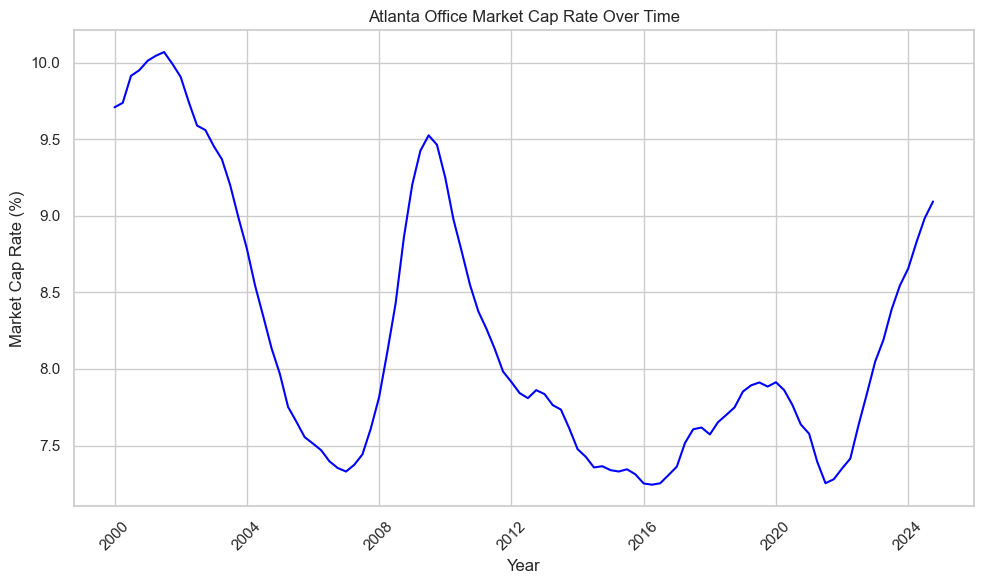

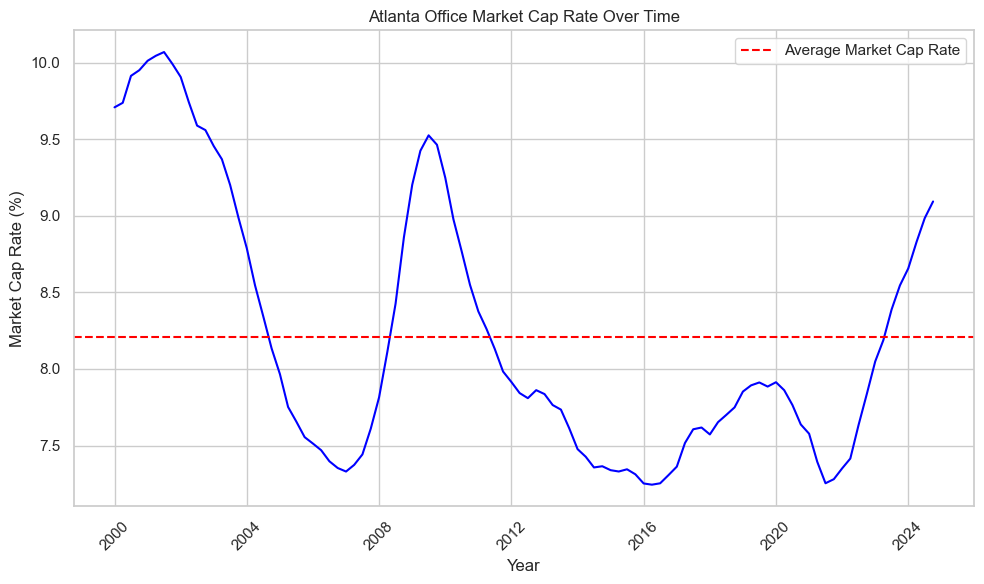

In [ ]:
#plot the market_cap_rate and do so with visually appealing colors use a theme that we will continue to use for other graphs

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='market_cap_rate', color='blue')
plt.title('Atlanta Office Market Cap Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Market Cap Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#include an average line in the above graph as well
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='market_cap_rate', color='blue')
plt.axhline(df['market_cap_rate'].mean(), color='red', linestyle='--', label='Average Market Cap Rate')
plt.title('Atlanta Office Market Cap Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Market Cap Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()





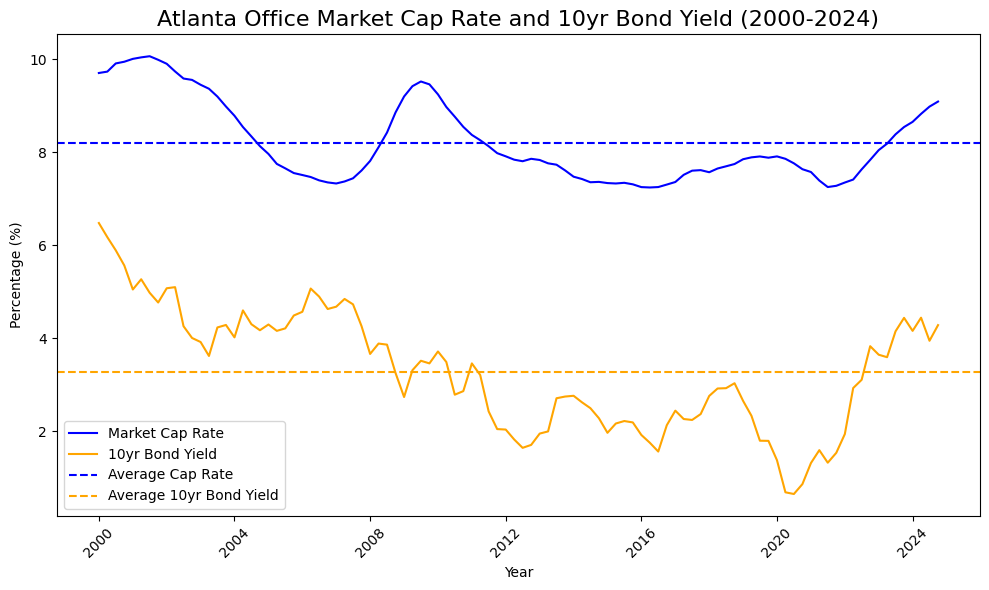

In [3]:
#plot both cap rates and 10yr bond yield on the same graph, include the average and a legend
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='market_cap_rate', color='blue', label='Market Cap Rate')
sns.lineplot(data=df, x='period', y='bond_yield_10yr_x', color='orange', label='10yr Bond Yield')
plt.axhline(df['market_cap_rate'].mean(), color='blue', linestyle='--', label='Average Cap Rate')
plt.axhline(df['bond_yield_10yr_x'].mean(), color='orange', linestyle='--', label='Average 10yr Bond Yield')
plt.title('Atlanta Office Market Cap Rate and 10yr Bond Yield (2000-2024)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



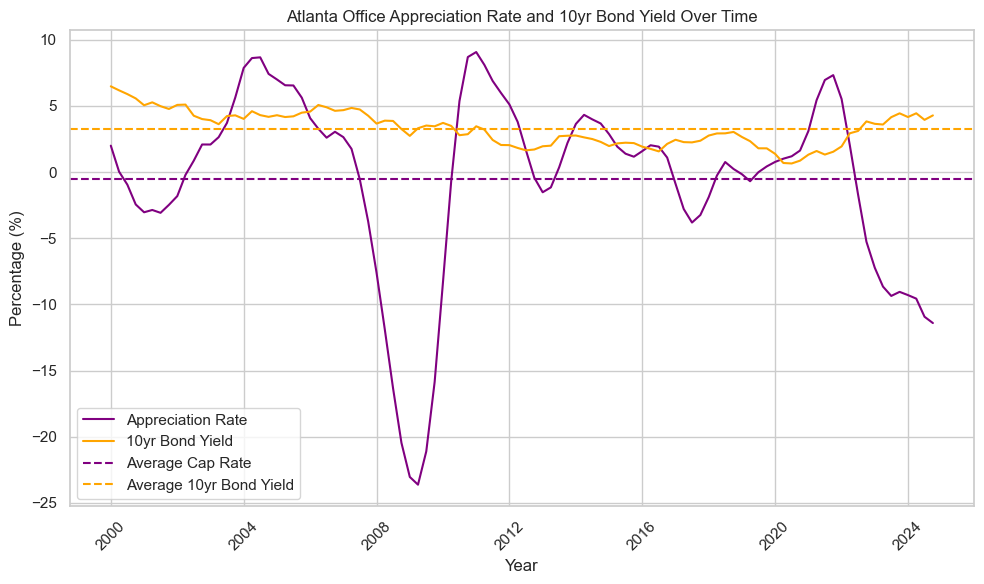

In [104]:
#plot both cap rates and 10yr bond yield on the same graph, include the average and a legend
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='appreciation_return', color='purple', label='Appreciation Rate')
sns.lineplot(data=df, x='period', y='bond_yield_10yr_x', color='orange', label='10yr Bond Yield')
plt.axhline(df['appreciation_return'].mean(), color='purple', linestyle='--', label='Average Cap Rate')
plt.axhline(df['bond_yield_10yr_x'].mean(), color='orange', linestyle='--', label='Average 10yr Bond Yield')
plt.title('Atlanta Office Appreciation Rate and 10yr Bond Yield Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



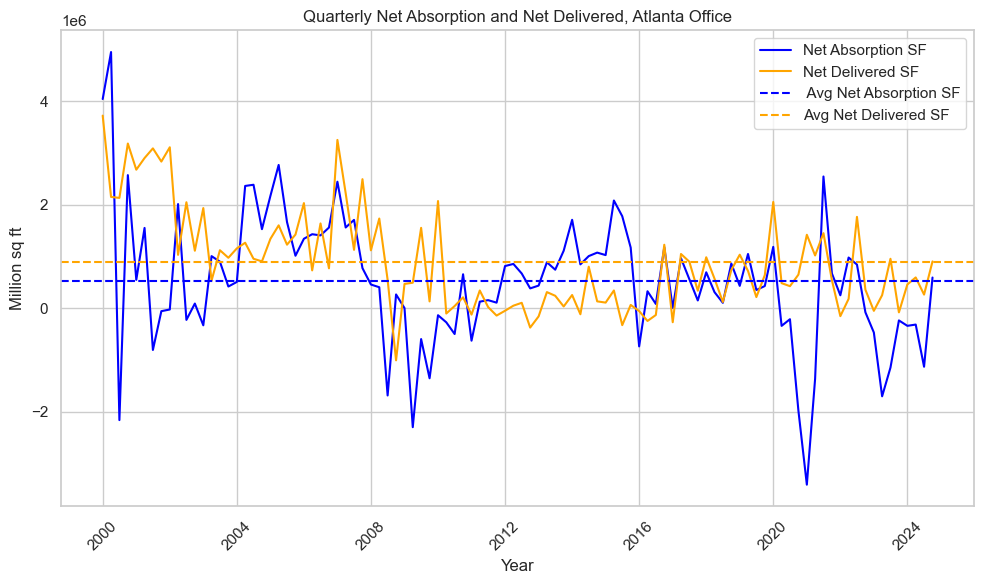

In [18]:
# melt the dataframe for the two variables



#plot both cap rates and 10yr bond yield on the same graph, include the average and a legend
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='net_absorp_sf', color='blue', label='Net Absorption SF')
sns.lineplot(data=df, x='period', y='net_delivered_sf', color='orange', label='Net Delivered SF')
plt.axhline(df['net_absorp_sf'].mean(), color='blue', linestyle='--', label=' Avg Net Absorption SF')
plt.axhline(df['net_delivered_sf'].mean(), color='orange', linestyle='--', label='Avg Net Delivered SF')
plt.title('Quarterly Net Absorption and Net Delivered, Atlanta Office')
plt.xlabel('Year')
plt.ylabel('Million sq ft')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()




In [13]:
#print net absorption for the periods from 2022 onwards
df[df['period'] >= '2022-01-01'][['period', 'net_absorp_sf', 'net_delivered_sf']]


,period,net_absorp_sf,net_delivered_sf
88,2022-01-01,249528.0,-154031.0
89,2022-04-01,979344.0,180222.0
90,2022-07-01,843236.0,1765919.0
91,2022-10-01,-79717.0,356854.0
92,2023-01-01,-470473.0,-51405.0
93,2023-04-01,-1704329.0,251046.0
94,2023-07-01,-1148997.0,955585.0
95,2023-10-01,-236803.0,-80866.0
96,2024-01-01,-341257.0,458130.0
97,2024-04-01,-316779.0,594841.0


In [10]:
#plot both cap rates and 10yr bond yield on the same graph, include the average and a legend
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='net_absorp', color='blue', label='Net Absorption SF')
sns.lineplot(data=df, x='period', y='bond_yield_10yr_x', color='orange', label='10yr Bond Yield')
plt.axhline(df['market_cap_rate'].mean(), color='blue', linestyle='--', label='Average Cap Rate')
plt.axhline(df['bond_yield_10yr_x'].mean(), color='orange', linestyle='--', label='Average 10yr Bond Yield')
plt.title('Atlanta Office Market Cap Rate and 10yr Bond Yield Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



ValueError: Could not interpret value `net_absorp` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [102]:
#print observations when market_cap_rate was greater than 9 between 2008 and 2012
df[(df['market_cap_rate'] > 9) & (df['period'] >= '2008-01-01') & (df['period'] <= '2011-01-01')]

,geography,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,...,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp,ten_yr_risk_premium,fed_funds_rate,cmbs_to_gdp,bond_yield_10yr_y,availability,cap_rate_bond_diff
36,Atlanta - GA USA,2009-01-01,-23.040996,0.171885,49072610.0,705853.0,7.616667,9.202290,279460.0,2048587.0,...,1.493725,1.548463,1.597175,1.641391,1.159297,0.183333,17.864254,2.736667,17.1885,6.465624
37,Atlanta - GA USA,2009-04-01,-23.624380,0.174964,49887216.0,1119938.0,NaN,9.424178,352569.0,1545880.0,...,1.753277,1.788944,1.822225,1.853562,1.198938,0.180000,17.825804,3.313333,17.4964,6.110845
38,Atlanta - GA USA,2009-07-01,-21.107876,0.179629,51593677.0,748491.0,9.000000,9.524802,435622.0,1658215.0,...,1.997986,2.022061,2.045451,2.068111,1.216488,0.156667,17.579256,3.516667,17.9629,6.008135
39,Atlanta - GA USA,2009-10-01,-15.864733,0.182651,52644525.0,761328.0,8.450000,9.463332,103285.0,1170936.0,...,1.878641,1.907684,1.935424,1.961976,1.178605,0.120000,17.110616,3.460000,18.2651,6.003332
40,Atlanta - GA USA,2010-01-01,-8.292996,0.185589,54156569.0,944126.0,9.413333,9.247815,461007.0,1352483.0,...,1.956525,1.985341,2.012468,2.038148,1.286749,0.133333,16.831762,3.716667,18.5589,5.531148


In [100]:
#create a mew columen where we calculate the difference between market_cap_rate and bond_yield_10yr_x
df['cap_rate_bond_diff'] = df['market_cap_rate'] - df['bond_yield_10yr_x']

In [101]:
#print cap_rate_bond_diff for row when period is 2024-10-01
df[df['period'] == '2024-10-01']['cap_rate_bond_diff']

99    4.809848
Name: cap_rate_bond_diff, dtype: float64

In [89]:
#print the average cap rate
print('Average Market Cap Rate:', df['market_cap_rate'].mean())

Average Market Cap Rate: 8.209433145821095


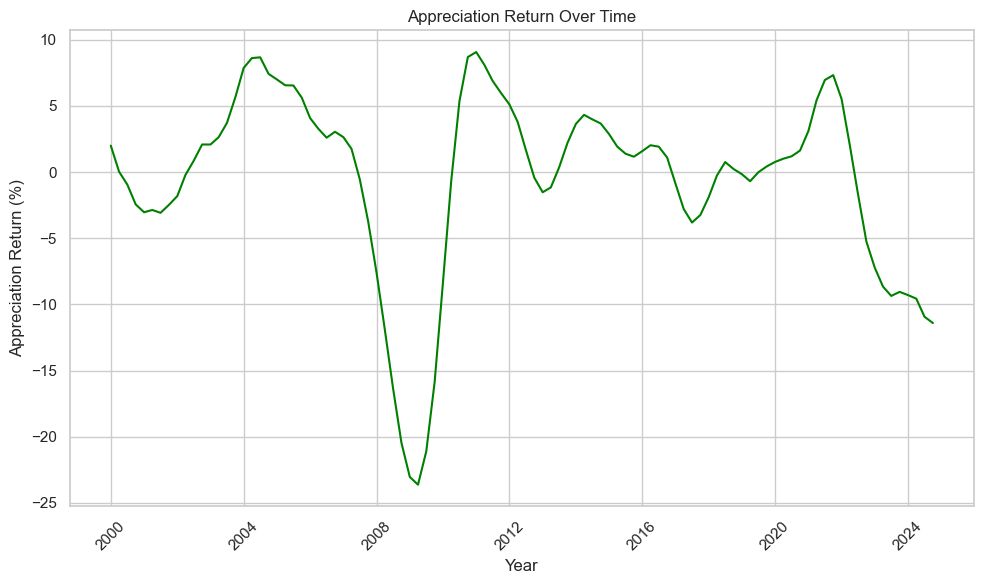

In [38]:
#graph the appreication_return
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='appreciation_return', color='green')
plt.title('Appreciation Return Over Time')
plt.xlabel('Year')
plt.ylabel('Appreciation Return (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


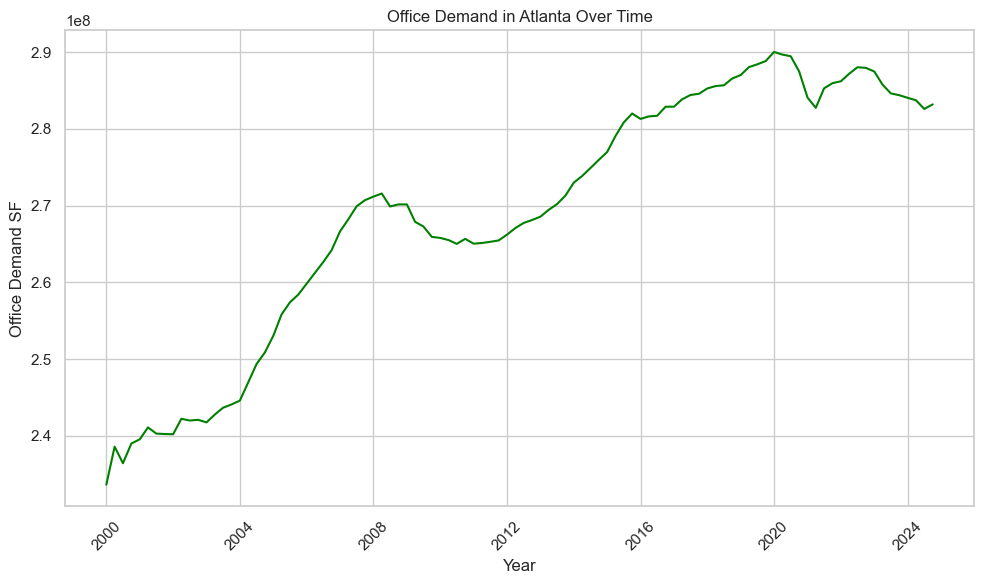

In [124]:
#graph the appreication_return
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='demand_sf', color='green')
plt.title('Office Demand in Atlanta Over Time')
plt.xlabel('Year')
plt.ylabel('Office Demand SF')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


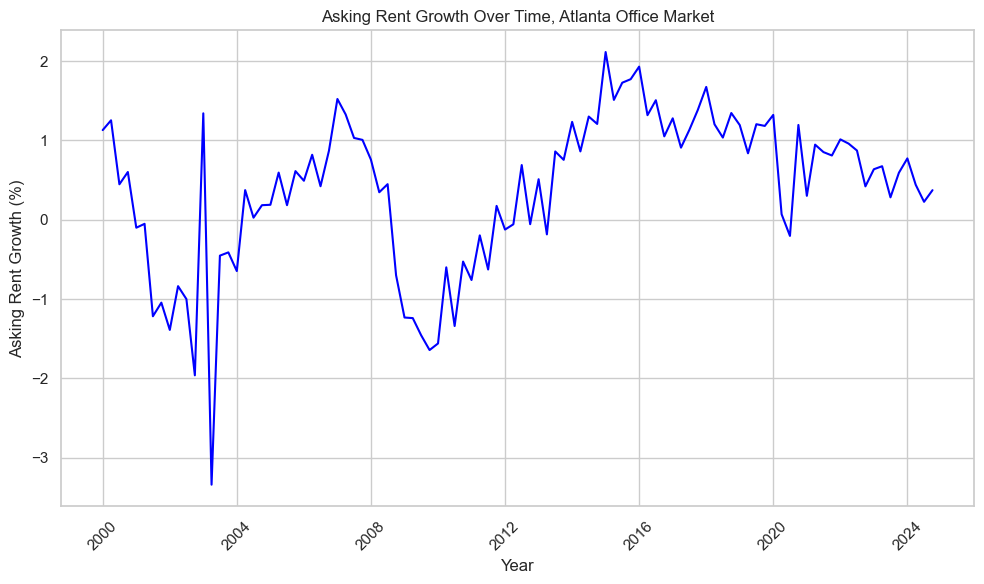

In [23]:
#graph the appreication_return
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='asking_rent_growth', color='blue')
plt.title('Asking Rent Growth Over Time, Atlanta Office Market')
plt.xlabel('Year')
plt.ylabel('Asking Rent Growth (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
#print variable names
print(df.columns)

Index(['geography', 'period', 'appreciation_return', 'availability_rate',
       'available_df_direct', 'avg_sale_price', 'cap_rate', 'market_cap_rate',
       'starts_sf', 'starts_sf_12_mo', 'demand_sf', 'demolished_sf',
       'gross_delivered_sf', 'inventory_sf', 'leasing_sf_total',
       'asking_rent_growth', 'asking_rent_growth_12_mo', 'net_absorp_sf',
       'net_absorp_sf_12_mo', 'net_delivered_sf', 'net_delivered_sf_12_mo',
       'occupancy_rate', 'sales_volume', 'sold_building_sf', 'vacancy_rate',
       'under_construction_sf', 'total_sales_transactions',
       'bond_yield_10yr_x', 'one_yr_inf_exp', 'two_yr_inf_exp',
       'three_yr_inf_exp', 'four_yr_inf_exp', 'five_yr_inf_exp',
       'six_yr_inf_exp', 'seven_yr_inf_exp', 'eight_yr_inf_exp',
       'nine_yr_inf_exp', 'ten_yr_inf_exp', 'ten_yr_risk_premium',
       'fed_funds_rate', 'cmbs_to_gdp', 'bond_yield_10yr_y', 'availability'],
      dtype='object')


In [43]:
#calculate the average appreciation return from 2021 quarter 1 to 2024 quarter 3
if 'period' in df.columns:
	df['period'] = pd.to_datetime(df['period'])
	df = df.set_index('period')
else:
	# if period is already the index, convert the index to datetime
	df.index = pd.to_datetime(df.index)
df = df.loc['2021-10-01':'2024-10-01']
avg_appreciation_return = df['appreciation_return'].mean()
print(f'The average appreciation return from 2021 quarter 1 to 2024 quarter 3 is {avg_appreciation_return}')


The average appreciation return from 2021 quarter 1 to 2024 quarter 3 is -5.196632244265994


In [45]:
#calculcat ethe annual appreciation_return average form 2021 to 2024
df['year'] = df.index.year
annual_avg_appreciation_return = df.groupby('year')['appreciation_return'].mean()
print(f'The annual average appreciation return from 2021 to 2024 is \n{annual_avg_appreciation_return}')

The annual average appreciation return from 2021 to 2024 is 
year
2021     7.326937
2022     0.154230
2023    -8.574004
2024   -10.301015
Name: appreciation_return, dtype: float64


/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_2877/1948763812.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df.index.year


In [50]:
df.shape

(13, 43)

In [70]:
office = pd.read_excel('../data/DataTable.xlsx')

In [73]:
office.head()

,Period,Asset Value,Vacancy Rate,Availability Rate,Available SF Direct,Available SF Sublet,Available SF Total,Market Asking Rent/SF,Market Asking Rent Growth,Inventory SF,Under Constr SF,Under Constr % of Inventory,12 Mo Net Absorp SF,Market Sale Price/SF,12 Mo Sales Vol,12 Mo Sales Vol Growth,Market Cap Rate
0,2030-01-01,72665615304.348694,0.171774,-,-,-,-,30.459398,0.015291,338677614,-,-,414561.0,213.12525,-,-,0.0806
1,2029-10-01,71800024158.675507,0.172099,-,-,-,-,30.339050,0.014841,338666866,-,-,366735.0,210.586507,-,-,0.0811
2,2029-07-01,70948242686.191696,0.172422,-,-,-,-,30.222488,0.01449,338671308,-,-,332358.0,208.088267,-,-,0.081699
3,2029-04-01,70112988967.107803,0.172746,-,-,-,-,30.109520,0.014124,338691684,-,-,296172.0,205.638502,-,-,0.082299
4,2029-01-01,69292683919.702103,0.173071,-,-,-,-,30.000648,0.01376,338728310,-,-,249213.0,203.232581,-,-,0.082899


In [72]:
#convert to time series
def convert_period_to_datetime(period):
	parts = period.split('Q')
	year = parts[0].strip()
	quarter = parts[1].strip().split()[0]
	month = (int(quarter) - 1) * 3 + 1
	return pd.Timestamp(year=int(year), month=month, day=1)

office['Period'] = office['Period'].apply(convert_period_to_datetime)

In [75]:
#print the Market Cap Rate for observation when Period is 2024-10-01
market_cap_rate_2024 = office.loc[office['Period'] == '2024-10-01', 'Market Cap Rate'].values[0]
print(f'The Market Cap Rate for 2024-10-01 is {market_cap_rate_2024}')  

The Market Cap Rate for 2024-10-01 is 0.0910713032977566


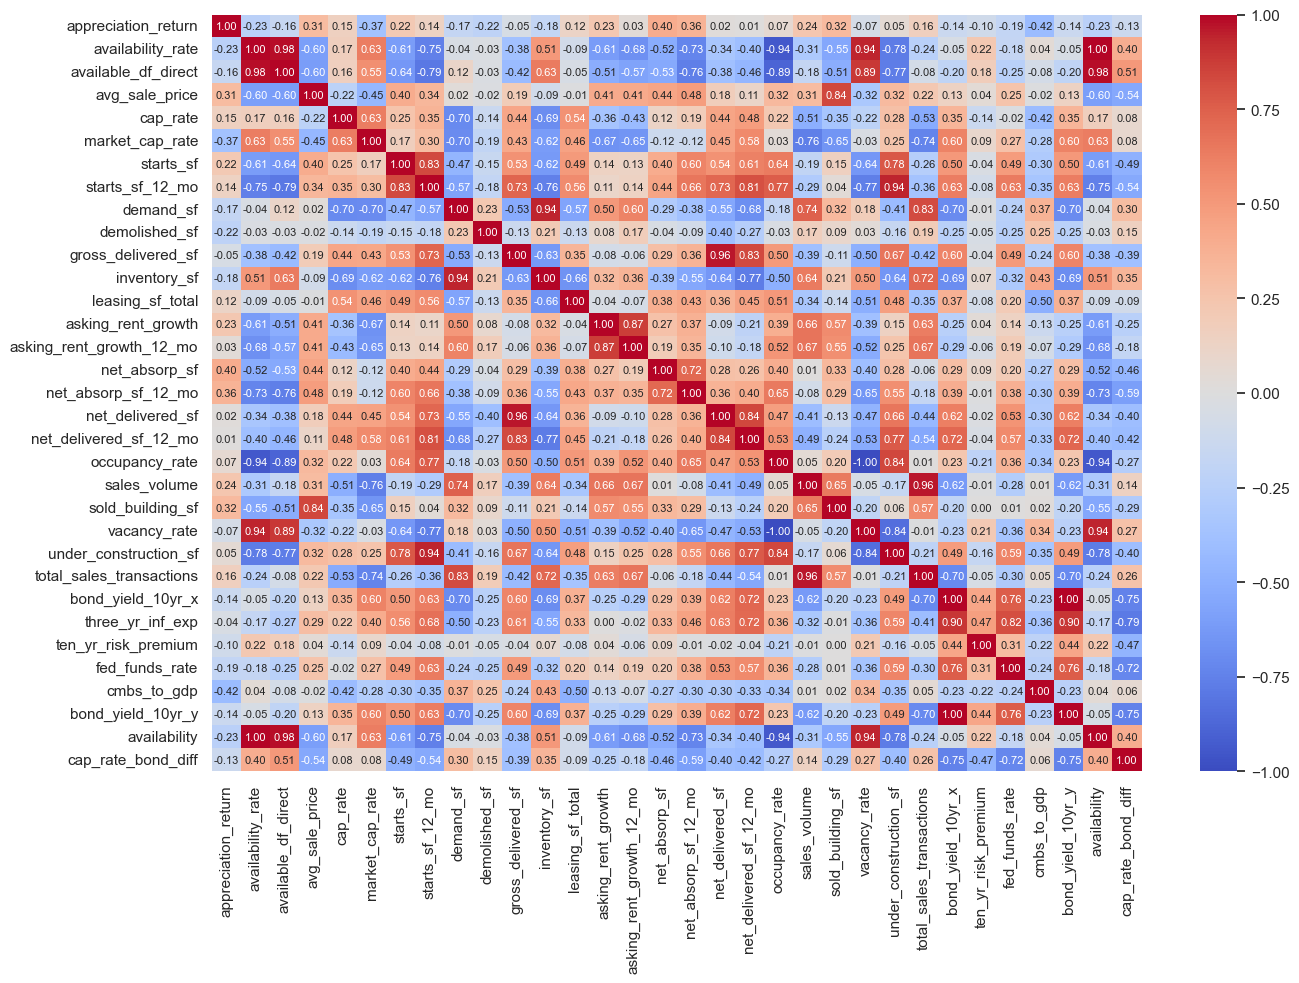

In [115]:
#generate a pearson correlation matrix for the df dataframe ignore the column geography, period, a
corr_matrix = df.drop(columns=['geography', 'period', 'one_yr_inf_exp', 'two_yr_inf_exp', 'four_yr_inf_exp','five_yr_inf_exp', 'six_yr_inf_exp', 'seven_yr_inf_exp', 'eight_yr_inf_exp', 'nine_yr_inf_exp', 'ten_yr_inf_exp']).select_dtypes(include=[np.number]).corr()
corr_matrix = corr_matrix.loc[:, ~corr_matrix.columns.str.endswith('exp')]
corr_matrix = corr_matrix.loc[:, ~corr_matrix.columns.isin(['two_yr_inf_exp'])]
#plot the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, annot_kws={"size": 8})
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



In [120]:
#print te highest correlations with market_cap_rate
highest_corr = corr_matrix['market_cap_rate'].sort_values(ascending=True)
print("Highest correlations with market_cap_rate:")
print(highest_corr[1:20])  # Exclude the first one as it's the correlation with itself

Highest correlations with market_cap_rate:
total_sales_transactions   -0.738033
demand_sf                  -0.695771
asking_rent_growth         -0.669823
asking_rent_growth_12_mo   -0.652972
sold_building_sf           -0.652660
inventory_sf               -0.615967
avg_sale_price             -0.451536
appreciation_return        -0.367267
cmbs_to_gdp                -0.275639
demolished_sf              -0.194893
net_absorp_sf_12_mo        -0.123535
net_absorp_sf              -0.119522
vacancy_rate               -0.031353
occupancy_rate              0.031353
cap_rate_bond_diff          0.078253
ten_yr_risk_premium         0.086615
starts_sf                   0.166358
under_construction_sf       0.253085
fed_funds_rate              0.272574
Name: market_cap_rate, dtype: float64


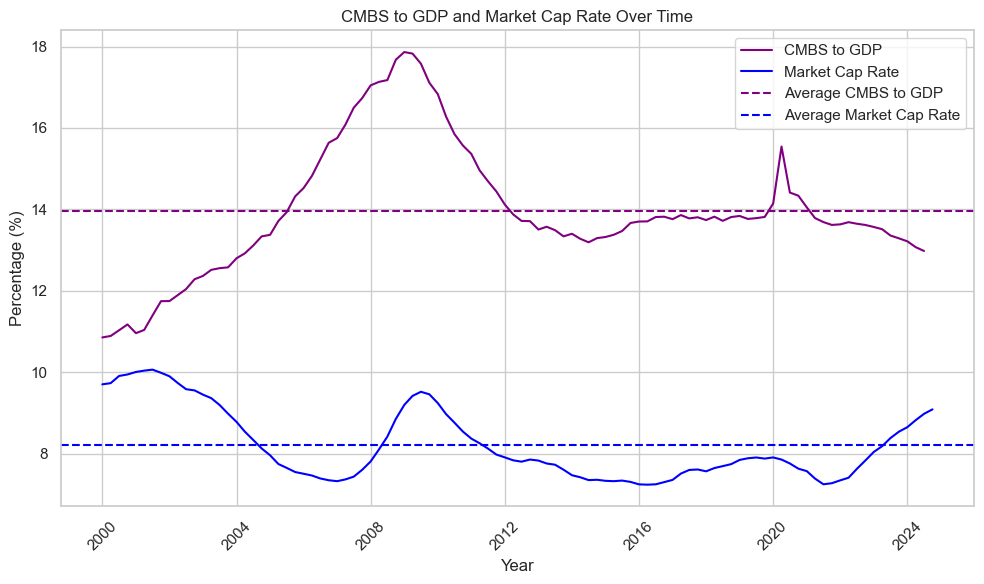

In [121]:
#plot the cmbs_to_gdp and market_cap_rate
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='period', y='cmbs_to_gdp', color='purple', label='CMBS to GDP')
sns.lineplot(data=df, x='period', y='market_cap_rate', color='blue', label='Market Cap Rate')
plt.axhline(df['cmbs_to_gdp'].mean(), color='purple', linestyle='--', label='Average CMBS to GDP')
plt.axhline(df['market_cap_rate'].mean(), color='blue', linestyle='--', label='Average Market Cap Rate')
plt.title('CMBS to GDP and Market Cap Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [122]:
df.shape

(100, 44)

In [123]:
#print variable names
print(df.columns)

Index(['geography', 'period', 'appreciation_return', 'availability_rate',
       'available_df_direct', 'avg_sale_price', 'cap_rate', 'market_cap_rate',
       'starts_sf', 'starts_sf_12_mo', 'demand_sf', 'demolished_sf',
       'gross_delivered_sf', 'inventory_sf', 'leasing_sf_total',
       'asking_rent_growth', 'asking_rent_growth_12_mo', 'net_absorp_sf',
       'net_absorp_sf_12_mo', 'net_delivered_sf', 'net_delivered_sf_12_mo',
       'occupancy_rate', 'sales_volume', 'sold_building_sf', 'vacancy_rate',
       'under_construction_sf', 'total_sales_transactions',
       'bond_yield_10yr_x', 'one_yr_inf_exp', 'two_yr_inf_exp',
       'three_yr_inf_exp', 'four_yr_inf_exp', 'five_yr_inf_exp',
       'six_yr_inf_exp', 'seven_yr_inf_exp', 'eight_yr_inf_exp',
       'nine_yr_inf_exp', 'ten_yr_inf_exp', 'ten_yr_risk_premium',
       'fed_funds_rate', 'cmbs_to_gdp', 'bond_yield_10yr_y', 'availability',
       'cap_rate_bond_diff'],
      dtype='object')


### Visualization for final project

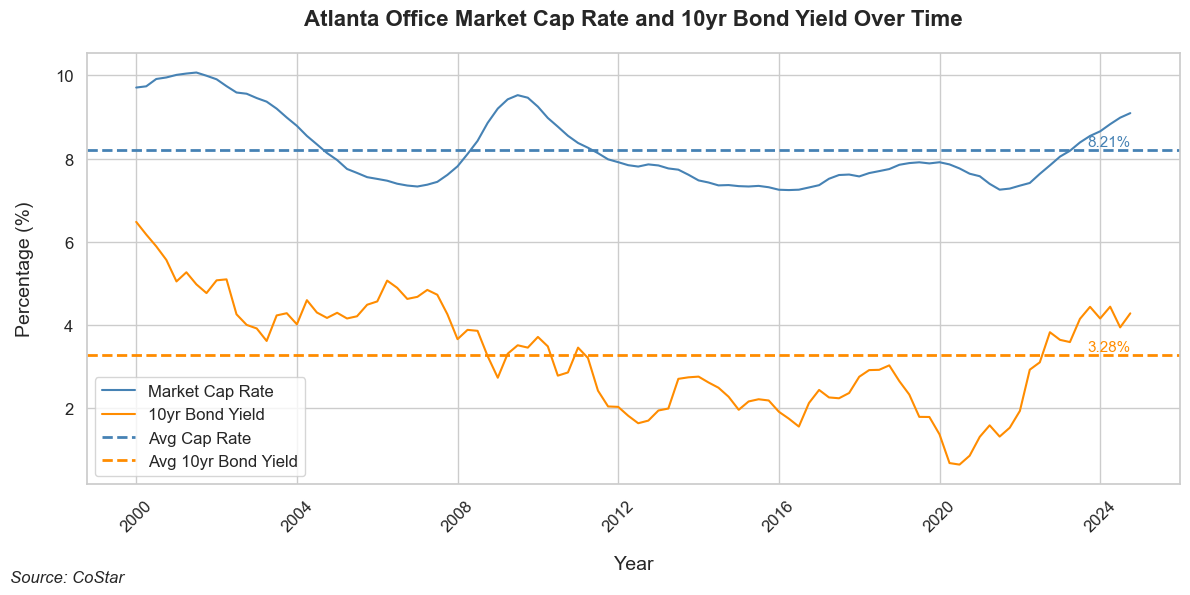

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Calculate averages
cap_avg = df['market_cap_rate'].mean()
bond_avg = df['bond_yield_10yr_x'].mean()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot lines
sns.lineplot(data=df, x='period', y='market_cap_rate', color='steelblue', label='Market Cap Rate')
sns.lineplot(data=df, x='period', y='bond_yield_10yr_x', color='darkorange', label='10yr Bond Yield')

# Historical average lines (dashed)
plt.axhline(cap_avg, color='steelblue', linestyle='--', linewidth=2, label='Avg Cap Rate')
plt.axhline(bond_avg, color='darkorange', linestyle='--', linewidth=2, label='Avg 10yr Bond Yield')

# Label lines (optional text positioning tweak)
plt.text(df['period'].iloc[-1], cap_avg + 0.1, f'{cap_avg:.2f}%', color='steelblue', fontsize=11, ha='right')
plt.text(df['period'].iloc[-1], bond_avg + 0.1, f'{bond_avg:.2f}%', color='darkorange', fontsize=11, ha='right')

# Title and axis labels with padding
plt.title('Atlanta Office Market Cap Rate and 10yr Bond Yield Over Time', fontsize=16, weight='bold', pad=20)
plt.xlabel('Year', fontsize=14, labelpad=15)
plt.ylabel('Percentage (%)', fontsize=14, labelpad=15)

# Format ticks
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Legend
plt.legend(fontsize=12)

# Tight layout
plt.tight_layout()

# Add source outside bottom-left
plt.figtext(0.01, 0.01, 'Source: CoStar', ha='left', va='bottom', fontsize=12, style='italic')

# Show plot
plt.show()


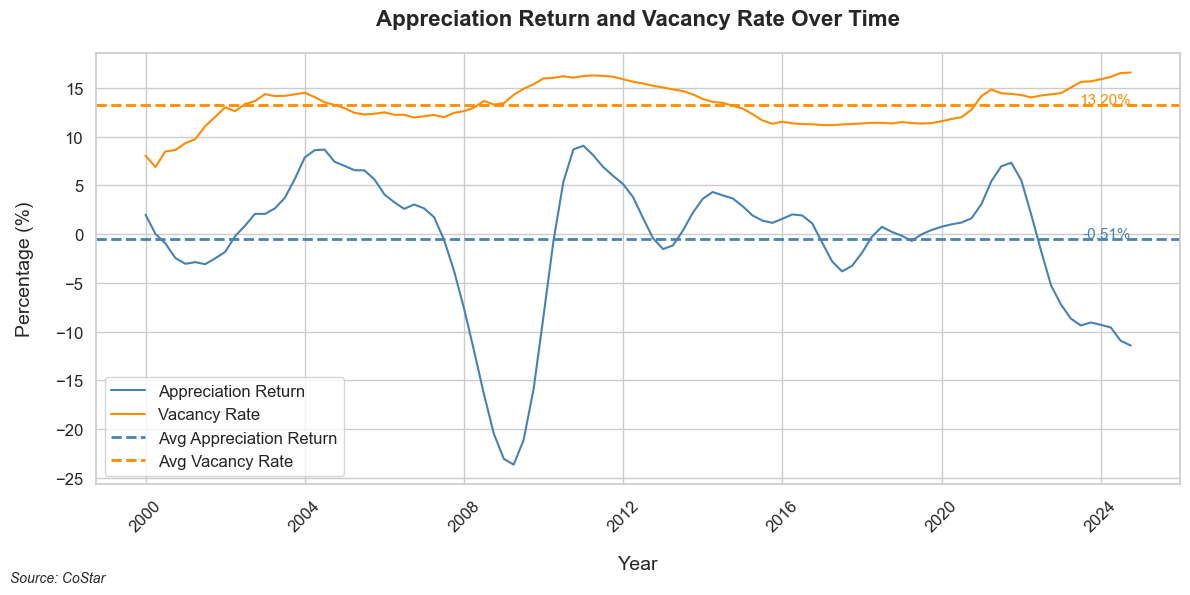

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Calculate averages
app_avg = df['appreciation_return'].mean()
vac_avg = df['vacancy_rate'].mean()

# Plot setup
plt.figure(figsize=(12, 6))

# Appreciation return line
sns.lineplot(data=df, x='period', y='appreciation_return', color='steelblue', label='Appreciation Return')

# Vacancy rate line
sns.lineplot(data=df, x='period', y='vacancy_rate', color='darkorange', label='Vacancy Rate')

# Dashed average lines
plt.axhline(app_avg, color='steelblue', linestyle='--', linewidth=2, label='Avg Appreciation Return')
plt.axhline(vac_avg, color='darkorange', linestyle='--', linewidth=2, label='Avg Vacancy Rate')

# Text labels near averages (optional)
plt.text(df['period'].iloc[-1], app_avg + 0.1, f'{app_avg:.2f}%', color='steelblue', fontsize=11, ha='right')
plt.text(df['period'].iloc[-1], vac_avg + 0.1, f'{vac_avg:.2f}%', color='darkorange', fontsize=11, ha='right')

# Title and labels with padding
plt.title('Appreciation Return and Vacancy Rate Over Time', fontsize=16, weight='bold', pad=20)
plt.xlabel('Year', fontsize=14, labelpad=15)
plt.ylabel('Percentage (%)', fontsize=14, labelpad=15)

# Ticks formatting
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Legend
plt.legend(fontsize=12)

# Layout
plt.tight_layout()

# Source label outside chart
plt.figtext(0.01, 0.01, 'Source: CoStar', ha='left', va='bottom', fontsize=10, style='italic')

plt.show()


In [10]:
#print the vacacny rate for 2024-10-01
vacancy_rate_2024 = df.loc[df['period'] == '2024-10-01', 'vacancy_rate'].values[0]
print(f'The Vacancy Rate for 2024-10-01 is {vacancy_rate_2024}')

The Vacancy Rate for 2024-10-01 is 16.5762349963188


In [11]:
#print the highest vacancy rate in the data
highest_vacancy_rate = df['vacancy_rate'].max()
print(f'The highest vacancy rate in the data is {highest_vacancy_rate}')

The highest vacancy rate in the data is 16.5762349963188


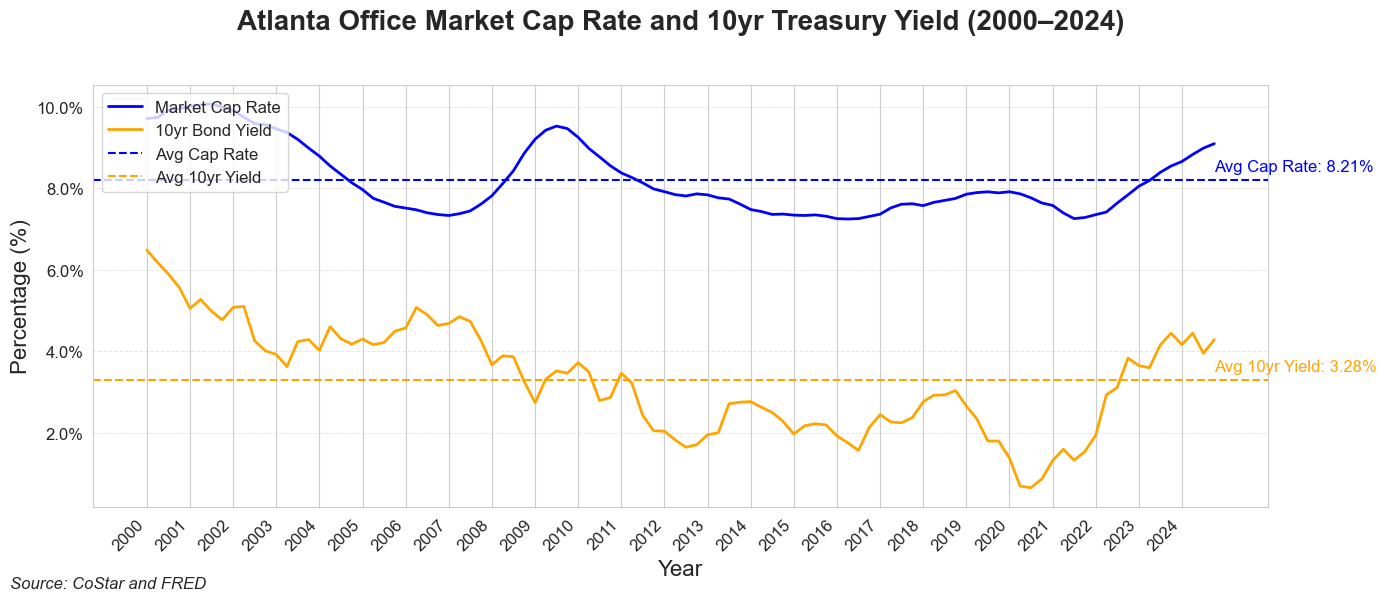

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import pandas as pd

# --- Data prep ---
df['period'] = pd.to_datetime(df['period'])
df = df.sort_values('period').copy()

# --- Apply style with grid
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))
ax = plt.gca()

# Plot cap rate and bond yield lines
sns.lineplot(data=df, x='period', y='market_cap_rate', color='blue', label='Market Cap Rate', ax=ax, linewidth=2)
sns.lineplot(data=df, x='period', y='bond_yield_10yr_x', color='orange', label='10yr Bond Yield', ax=ax, linewidth=2)

# Calculate and plot average lines
avg_cap_rate = df['market_cap_rate'].mean()
avg_bond_yield = df['bond_yield_10yr_x'].mean()

ax.axhline(avg_cap_rate, color='blue', linestyle='--', linewidth=1.5, label='Avg Cap Rate')
ax.axhline(avg_bond_yield, color='orange', linestyle='--', linewidth=1.5, label='Avg 10yr Yield')

# Annotate average values directly on the plot
y_buffer = 0.15  # vertical offset for label
x_pos = df['period'].iloc[-1]  # place label at the end of the time series

ax.text(x_pos, avg_cap_rate + y_buffer, f'Avg Cap Rate: {avg_cap_rate:.2f}%', color='blue', fontsize=12, va='bottom')
ax.text(x_pos, avg_bond_yield + y_buffer, f'Avg 10yr Yield: {avg_bond_yield:.2f}%', color='orange', fontsize=12, va='bottom')

# X-axis formatting
ax.set_xlabel('Year', fontsize=16)
ax.set_xticks(df['period'][::4])  # optional: reduce number of tick labels
ax.set_xticklabels(df['period'][::4].dt.year, rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='x', labelsize=12)

# Y-axis formatting
ax.set_ylabel('Percentage (%)', fontsize=16)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.tick_params(axis='y', labelsize=12)

# Title
plt.title('Atlanta Office Market Cap Rate and 10yr Treasury Yield (2000–2024)', fontsize=20, weight='bold', pad=40)

# Gridlines
ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

# Legend
ax.legend(loc='upper left', fontsize=12)

# Source
plt.figtext(0.01, 0.01, 'Source: CoStar and FRED', ha='left', fontsize=12, style='italic')

plt.tight_layout()
plt.show()
